In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import matplotlib.pyplot as plt
import os

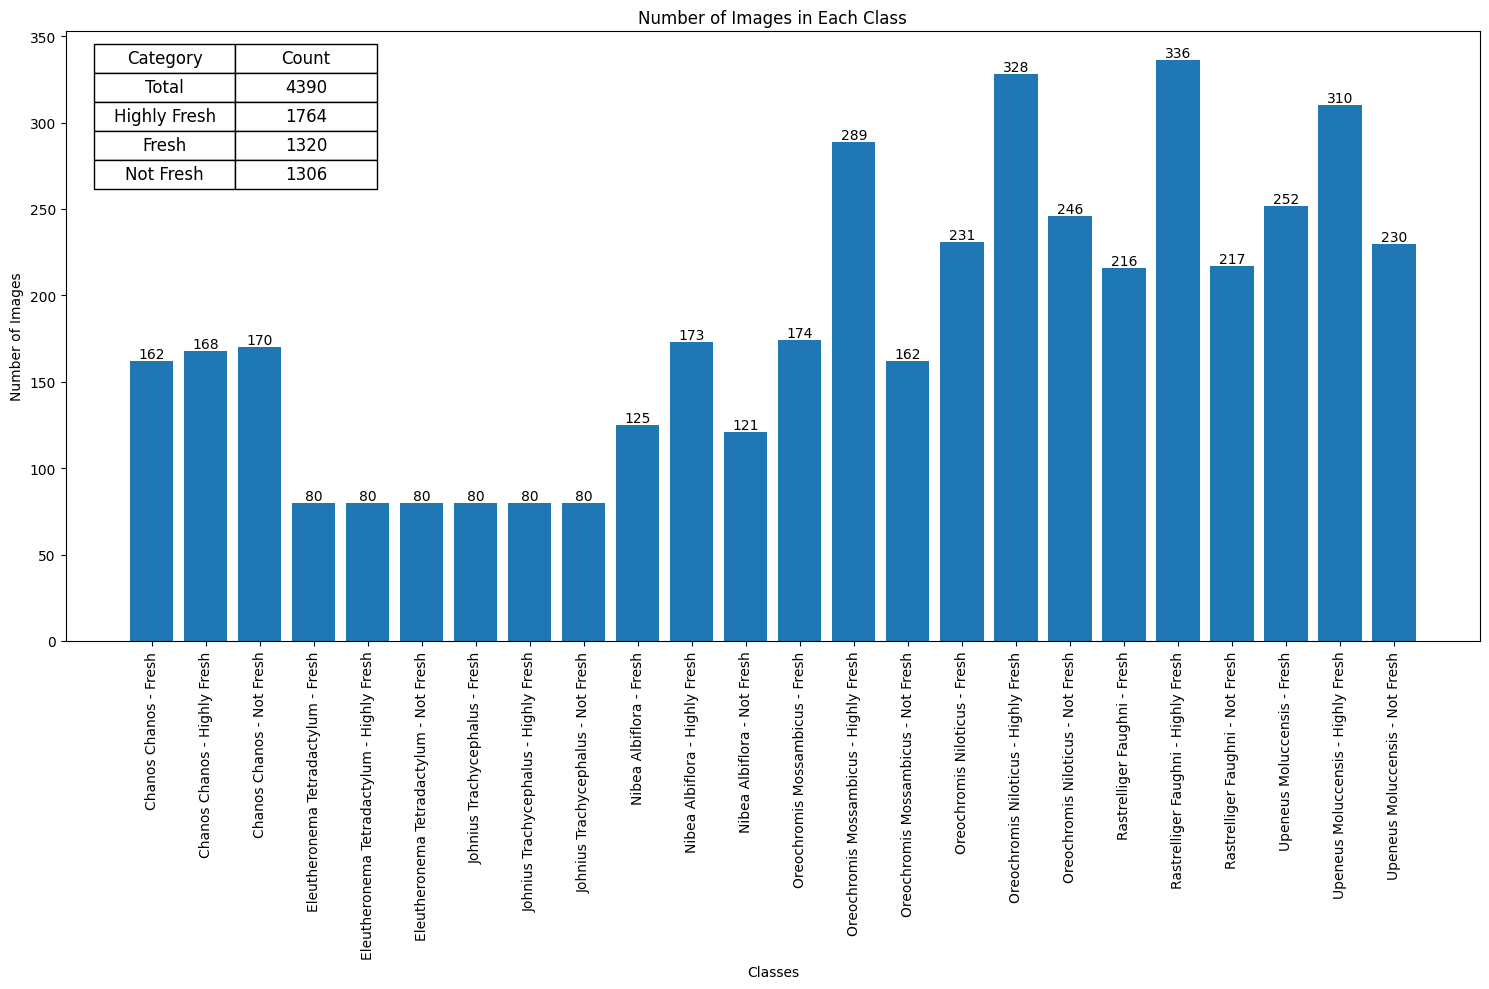

In [3]:
mainfolder_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1'
# Get a list of all subfolders in the parent folder
subfolders = []
image_counts = []
Highly_Fresh = 0
Fresh = 0
Not_Fresh = 0
for f in sorted(os.listdir(mainfolder_path)):
    folder_path = os.path.join(mainfolder_path, f)
    if os.path.isdir(folder_path):
        if '- Highly Fresh' in f:
            Highly_Fresh += len(os.listdir(folder_path))
            subfolders.append(f)
            image_counts.append(len(os.listdir(folder_path)))
        elif '- Fresh' in f:
            Fresh += len(os.listdir(folder_path))
            subfolders.append(f)
            image_counts.append(len(os.listdir(folder_path)))
        elif '- Not Fresh' in f:
            Not_Fresh += len(os.listdir(folder_path))
            subfolders.append(f)
            image_counts.append(len(os.listdir(folder_path)))


total_count = sum(image_counts)

# Create a bar plot
plt.figure(figsize=(15, 10))
plt.title("Number of Images in Each Class")
plt.bar(range(len(subfolders)), image_counts)

# Also display the count above each bar
for i, count in enumerate(image_counts):
    plt.text(i, count, str(count), ha='center', va='bottom')

# Set the x-axis labels to be the subfolder names
plt.xlabel("Classes")
plt.ylabel("Number of Images")

# Rotate x-axis labels to 90 degrees
plt.xticks(range(len(subfolders)), subfolders, rotation=90)

# Rotate x-axis labels to 90 degrees
plt.xticks(range(len(subfolders)), subfolders, rotation=90)

# Add a table with total, Highly Fresh, Fresh, and Not Fresh counts
cell_text = [
    ['Total', total_count],
    ['Highly Fresh', Highly_Fresh],
    ['Fresh', Fresh],
    ['Not Fresh', Not_Fresh]
]

# Create the table
table = plt.table(cellText=cell_text,
                  colLabels=['Category', 'Count'],
                  cellLoc='center',
                  loc='upper left')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(0.2, 2.2)

# Display the plot
plt.tight_layout()
plt.show()


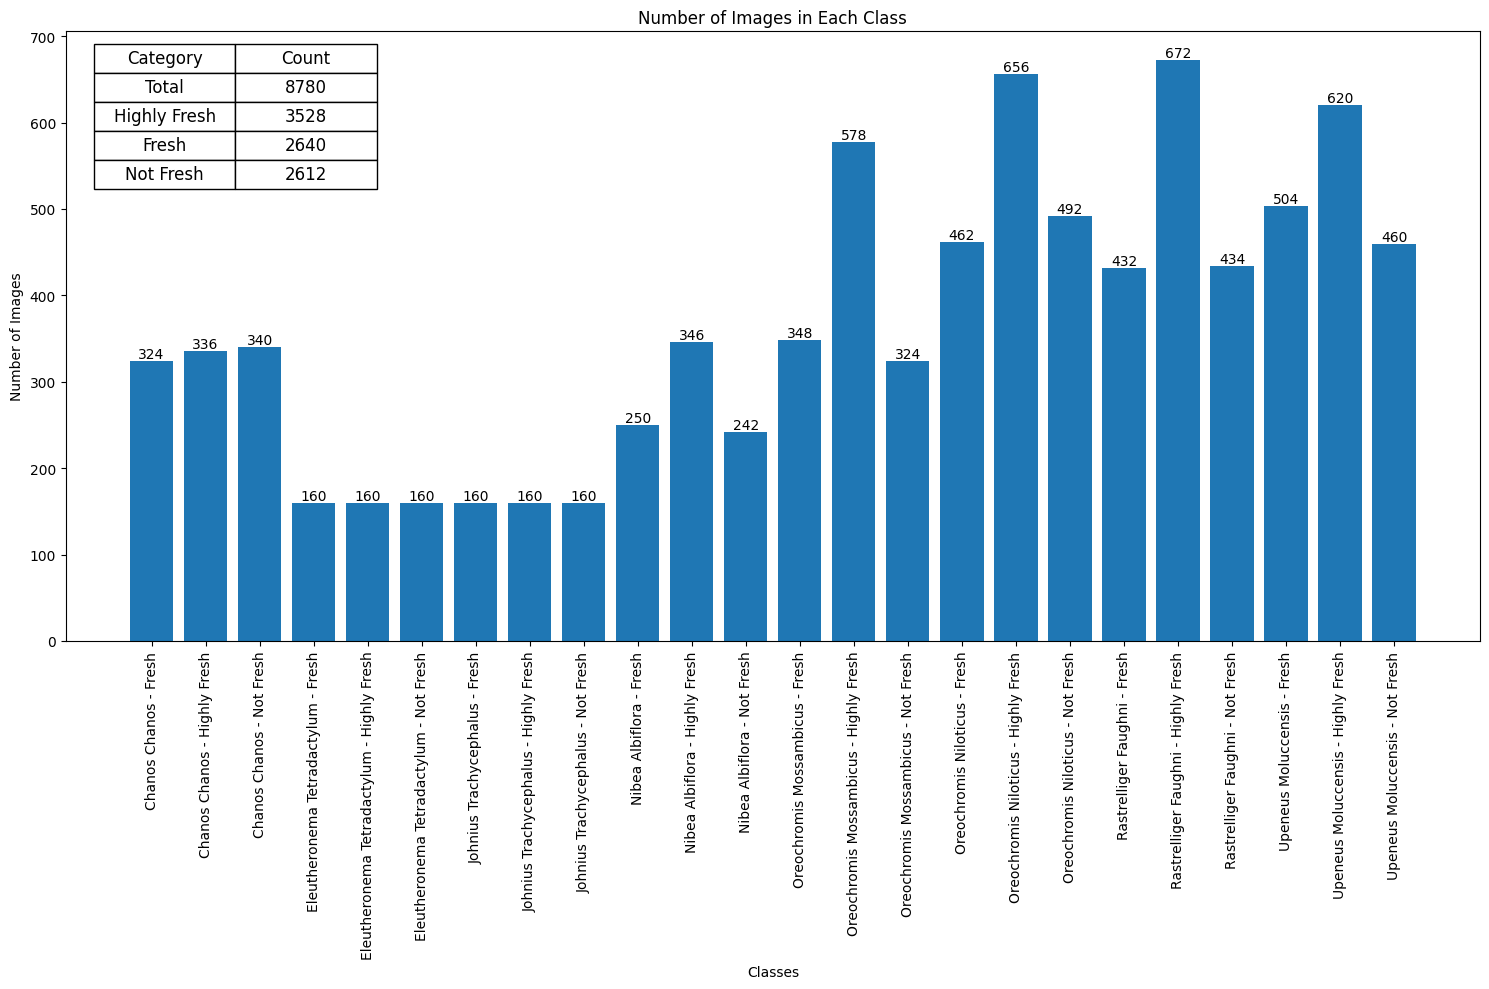

In [4]:
combined_data = mainfolder_path + '/combined_data'

# Get a list of all subfolders in the parent folder
subfolders = []
image_counts = []
Highly_Fresh = 0
Fresh = 0
Not_Fresh = 0
for f in sorted(os.listdir(combined_data)):
    folder_path = os.path.join(combined_data, f)
    if os.path.isdir(folder_path):
        if '- Highly Fresh' in f:
            Highly_Fresh += len(os.listdir(folder_path))
            subfolders.append(f)
            image_counts.append(len(os.listdir(folder_path)))
        elif '- Fresh' in f:
            Fresh += len(os.listdir(folder_path))
            subfolders.append(f)
            image_counts.append(len(os.listdir(folder_path)))
        elif '- Not Fresh' in f:
            Not_Fresh += len(os.listdir(folder_path))
            subfolders.append(f)
            image_counts.append(len(os.listdir(folder_path)))


total_count = sum(image_counts)

# Create a bar plot
plt.figure(figsize=(15, 10))
plt.title("Number of Images in Each Class")
plt.bar(range(len(subfolders)), image_counts)

# Also display the count above each bar
for i, count in enumerate(image_counts):
    plt.text(i, count, str(count), ha='center', va='bottom')

# Set the x-axis labels to be the subfolder names
plt.xlabel("Classes")
plt.ylabel("Number of Images")

# Rotate x-axis labels to 90 degrees
plt.xticks(range(len(subfolders)), subfolders, rotation=90)

# Rotate x-axis labels to 90 degrees
plt.xticks(range(len(subfolders)), subfolders, rotation=90)

# Add a table with total, Highly Fresh, Fresh, and Not Fresh counts
cell_text = [
    ['Total', total_count],
    ['Highly Fresh', Highly_Fresh],
    ['Fresh', Fresh],
    ['Not Fresh', Not_Fresh]
]

# Create the table
table = plt.table(cellText=cell_text,
                  colLabels=['Category', 'Count'],
                  cellLoc='center',
                  loc='upper left')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(0.2, 2.2)

# Display the plot
plt.tight_layout()
plt.show()


In [5]:
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Load the VGG19 model pre-trained on ImageNet
vgg19 = VGG19(weights='imagenet')

# Create a model that outputs activations from the penultimate layer (fc2)
model = Model(inputs=vgg19.input, outputs=vgg19.get_layer('fc2').output)

def extract_features_single_img(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    print(type(img))
    img_data = image.img_to_array(img)
    print(img_data.shape)
    img_data = np.expand_dims(img_data, axis=0)
    print(img_data.shape)
    img_data = preprocess_input(img_data)
    print(img_data.shape)
    fc2_features = model.predict(img_data)
    print(fc2_features.shape)
    print(fc2_features.flatten().shape)
    return fc2_features.flatten()

# Example usage:
# features = extract_features_single_img('/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/Chanos Chanos - Fresh/IMG_20191002_062711.jpg',
#                             model)

574710816/574710816 [==============================] - 3s 0us/step


In [4]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load the VGG19 model pre-trained on ImageNet
vgg19 = VGG19(weights='imagenet')
# Create a model that outputs activations from the penultimate layer (fc2)
model = Model(inputs=vgg19.input, outputs=vgg19.get_layer('fc2').output)

def extract_features(img_paths, model):
    features = []
    for img_path in img_paths:
        img = image.load_img(img_path, target_size=(224, 224))
        img_data = image.img_to_array(img)
        img_data = np.expand_dims(img_data, axis=0)
        img_data = preprocess_input(img_data)
        fc2_features = model.predict(img_data, verbose=0)
        features.append(fc2_features.flatten())
    return np.array(features)

# Define the dataset directory
dataset_dir = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/combined_data'

# Prepare a DataFrame
data = []

# List all directories in the dataset directory
class_dirs = os.listdir(dataset_dir)

for class_dir in class_dirs:
    # Determine the freshness category based on folder name
    if '- Highly Fresh' in class_dir:
        freshness_label = 'Highly Fresh'
    elif '- Fresh' in class_dir:
        freshness_label = 'Fresh'
    elif '- Not Fresh' in class_dir:
        freshness_label = 'Not Fresh'
    else:
        continue

    # List all image files in the class directory
    image_files = os.listdir(os.path.join(dataset_dir, class_dir))

    for img_name in image_files:
        img_path = os.path.join(dataset_dir, class_dir, img_name)
        data.append((img_path, freshness_label))

df = pd.DataFrame(data, columns=['img_path', 'freshness_label'])

574710816/574710816 [==============================] - 5s 0us/step


In [5]:
df

,img_path,freshness_label
0,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Fresh
1,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Fresh
2,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Fresh
3,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Fresh
4,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Fresh
...,...,...
8775,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Highly Fresh
8776,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Highly Fresh
8777,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Highly Fresh
8778,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Highly Fresh


In [6]:
df['freshness_label'].value_counts()

freshness_label
Highly Fresh    3528
Fresh           2640
Not Fresh       2612
Name: count, dtype: int64

In [7]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)

In [8]:
df.shape, test_df.shape, train_df.shape

((8780, 2), (1756, 2), (7024, 2))

In [11]:
df = train_df

In [12]:
# Extract features for all images
X = extract_features(df['img_path'].tolist(), model)

# Map freshness labels to numerical values
label_mapping = {
    'Highly Fresh': 0,
    'Fresh': 1,
    'Not Fresh': 2
}
y = df['freshness_label'].map(label_mapping).values
# y = to_categorical(y, num_classes=3)  # Convert labels to one-hot encoding

Streaming output truncated to the last 5000 lines.
1/1 [==============================] - 1s 651ms/step


In [20]:
y = df['freshness_label'].map(label_mapping).values
y.shape

(7024,)

In [40]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, make_scorer

# Define the ANN model parameters
ann_params = {
    'hidden_layer_sizes': (100,),
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,
    'max_iter': 500,
    'random_state': 42
}

# Custom scoring function for classification report
def classification_report_with_accuracy_score(y_true, y_pred):
    print(classification_report(y_true, y_pred, target_names=label_mapping.keys()))
    return accuracy_score(y_true, y_pred)

# Initialize the ANN model
ann = MLPClassifier(**ann_params)

# Define the cross-validation strategy
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize scaler
scaler = StandardScaler()

# Cross-validate the model
results = cross_validate(
    ann, scaler.fit_transform(X), y, cv=skf, scoring={
          'accuracy': make_scorer(accuracy_score),
          'classification_report': make_scorer(classification_report_with_accuracy_score)
          },
    return_train_score=True
)

# Print cross-validation results
print(f"Train Accuracy: {results['train_accuracy'].mean():.4f} ± {results['train_accuracy'].std():.4f}")
print(f"Test Accuracy: {results['test_accuracy'].mean():.4f} ± {results['test_accuracy'].std():.4f}")


              precision    recall  f1-score   support

Highly Fresh       0.83      0.85      0.84       564
       Fresh       0.77      0.76      0.77       423
   Not Fresh       0.80      0.78      0.79       418

    accuracy                           0.80      1405
   macro avg       0.80      0.80      0.80      1405
weighted avg       0.80      0.80      0.80      1405

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00      2256
       Fresh       1.00      1.00      1.00      1688
   Not Fresh       1.00      1.00      1.00      1675

    accuracy                           1.00      5619
   macro avg       1.00      1.00      1.00      5619
weighted avg       1.00      1.00      1.00      5619

              precision    recall  f1-score   support

Highly Fresh       0.82      0.87      0.84       564
       Fresh       0.78      0.72      0.75       422
   Not Fresh       0.81      0.81      0.81       419

    accuracy        

In [43]:
# Train the model on the entire dataset
X_scaled = scaler.fit_transform(X)  # Scale the features
ann.fit(X_scaled, y)

MLPClassifier(max_iter=500, random_state=42)

In [80]:
y_pred = ann.predict(X_scaled)

# Evaluate the predictions
print(classification_report(y, y_pred, target_names=label_mapping.keys()))
print("Accuracy:", accuracy_score(y, y_pred))

              precision    recall  f1-score   support

Highly Fresh       1.00      1.00      1.00      2820
       Fresh       1.00      1.00      1.00      2111
   Not Fresh       1.00      1.00      1.00      2093

    accuracy                           1.00      7024
   macro avg       1.00      1.00      1.00      7024
weighted avg       1.00      1.00      1.00      7024

Accuracy: 1.0


Test the model

In [41]:
test_df

,img_path,freshness_label
2157,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Fresh
2586,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Fresh
2321,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Not Fresh
4629,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Highly Fresh
2807,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Highly Fresh
...,...,...
8200,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Not Fresh
694,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Not Fresh
4701,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Highly Fresh
4379,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/co...,Highly Fresh


In [47]:
import pandas as pd
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.utils import to_categorical
from sklearn.neural_network import MLPClassifier
from tqdm import tqdm

# Load the VGG19 model pre-trained on ImageNet
vgg19 = VGG19(weights='imagenet')
# Create a model that outputs activations from the penultimate layer (fc2)
model = Model(inputs=vgg19.input, outputs=vgg19.get_layer('fc2').output)

def extract_features(img_paths, model):
    features = []
    for img_path in tqdm(img_paths):
        img = image.load_img(img_path, target_size=(224, 224))
        img_data = image.img_to_array(img)
        img_data = np.expand_dims(img_data, axis=0)
        img_data = preprocess_input(img_data)
        fc2_features = model.predict(img_data, verbose=0)
        features.append(fc2_features.flatten())
    return np.array(features)

# Assuming you have a pandas DataFrame `df_unseen_data` with columns 'img_path' and 'freshness_label'
# Load your unseen data
# Example:
# df_unseen_data = pd.read_csv('path_to_unseen_data.csv')

df_unseen_data = test_df

# Extract features for unseen data
X_unseen = extract_features(df_unseen_data['img_path'].tolist(), model)

# Map freshness labels to numerical values (if needed)
label_mapping = {
    'Highly Fresh': 0,
    'Fresh': 1,
    'Not Fresh': 2
}

# Convert labels to numerical values (if needed)
y_unseen = df_unseen_data['freshness_label'].map(label_mapping).values
# y_unseen = to_categorical(y_unseen, num_classes=3)  # Convert labels to one-hot encoding

100%|██████████| 1756/1756 [24:02<00:00,  1.22it/s]


NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

used different scalers for training and testing

In [58]:
# Normalize the features
scaler = StandardScaler()
X_unseen = scaler.fit_transform(X_unseen)

# Assuming `ann` is your trained MLPClassifier model
# Make predictions on unseen data
y_pred_unseen = ann.predict(X_unseen)

# Evaluate the predictions
print(classification_report(y_unseen, y_pred_unseen, target_names=label_mapping.keys()))
print("Accuracy:", accuracy_score(y_unseen, y_pred_unseen))


              precision    recall  f1-score   support

Highly Fresh       0.86      0.88      0.87       708
       Fresh       0.79      0.77      0.78       529
   Not Fresh       0.81      0.82      0.81       519

    accuracy                           0.82      1756
   macro avg       0.82      0.82      0.82      1756
weighted avg       0.82      0.82      0.82      1756

Accuracy: 0.8246013667425968


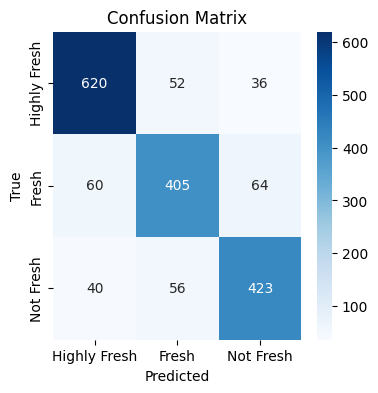

In [59]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Compute the confusion matrix
conf_matrix = confusion_matrix(y_unseen, y_pred_unseen)

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

used same scaler for both training and testing

In [53]:
# Normalize the features
X_unseen = scaler.transform(X_unseen)

# Assuming `ann` is your trained MLPClassifier model
# Make predictions on unseen data
y_pred_unseen = ann.predict(X_unseen)

# Evaluate the predictions
print(classification_report(y_unseen, y_pred_unseen, target_names=label_mapping.keys()))
print("Accuracy:", accuracy_score(y_unseen, y_pred_unseen))

              precision    recall  f1-score   support

Highly Fresh       0.77      0.50      0.61       708
       Fresh       0.44      0.78      0.56       529
   Not Fresh       0.65      0.45      0.53       519

    accuracy                           0.57      1756
   macro avg       0.62      0.58      0.57      1756
weighted avg       0.64      0.57      0.57      1756

Accuracy: 0.5689066059225513


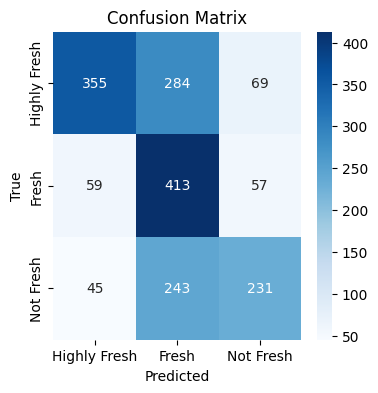

In [57]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Compute the confusion matrix
conf_matrix = confusion_matrix(y_unseen, y_pred_unseen)

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

test indian salmon

In [60]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.utils import to_categorical
from sklearn.neural_network import MLPClassifier

# Load the VGG19 model pre-trained on ImageNet
vgg19 = VGG19(weights='imagenet')
# Create a model that outputs activations from the penultimate layer (fc2)
model = Model(inputs=vgg19.input, outputs=vgg19.get_layer('fc2').output)

def extract_features(img_paths, model):
    features = []
    for img_path in tqdm(img_paths):
        img = image.load_img(img_path, target_size=(224, 224))
        img_data = image.img_to_array(img)
        img_data = np.expand_dims(img_data, axis=0)
        img_data = preprocess_input(img_data)
        fc2_features = model.predict(img_data, verbose=0)
        features.append(fc2_features.flatten())
    return np.array(features)

# Define the folder path containing your unseen data
# unseen_data_folder = 'path_to_unseen_data_folder'
unseen_data_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes/Indian salmon'

# Prepare a DataFrame for unseen data
data = []
class_mapping = {
    'Highly Fresh': 0,
    'Fresh': 1,
    'Not Fresh': 2
}

# Iterate over the folders in the unseen data folder
for class_dir in os.listdir(unseen_data_folder):
    # Check if the class is one of the classes you trained on
    if class_dir in class_mapping:
        class_label = class_mapping[class_dir]
        class_path = os.path.join(unseen_data_folder, class_dir)
        # List all image files in the class directory
        image_files = os.listdir(class_path)
        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            data.append((img_path, class_label))

# Create a DataFrame
df_unseen_data = pd.DataFrame(data, columns=['img_path', 'class_label'])

# Extract features for unseen data
X_unseen = extract_features(df_unseen_data['img_path'].tolist(), model)

# Convert labels to numerical values (if needed)
y_unseen = df_unseen_data['class_label'].map(class_mapping).values

100%|██████████| 616/616 [08:41<00:00,  1.18it/s]


In [65]:
df_unseen_data

,img_path,class_label
0,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,2
1,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,2
2,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,2
3,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,2
4,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,2
...,...,...
611,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,1
612,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,1
613,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,1
614,/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/wa...,1


In [66]:
y_unseen = df_unseen_data['class_label'].values

using different scalers for training and testing



In [68]:
# Normalize the features
scaler = StandardScaler()
X_unseen = scaler.fit_transform(X_unseen)

# Assuming `ann` is your trained MLPClassifier model
# Make predictions on unseen data
y_pred_unseen = ann.predict(X_unseen)

# Evaluate the predictions
print(classification_report(y_unseen, y_pred_unseen))
print("Accuracy:", accuracy_score(y_unseen, y_pred_unseen))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.95      0.29      0.45       582
           2       0.04      0.21      0.07        34

    accuracy                           0.29       616
   macro avg       0.33      0.17      0.17       616
weighted avg       0.90      0.29      0.43       616

Accuracy: 0.28733766233766234


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


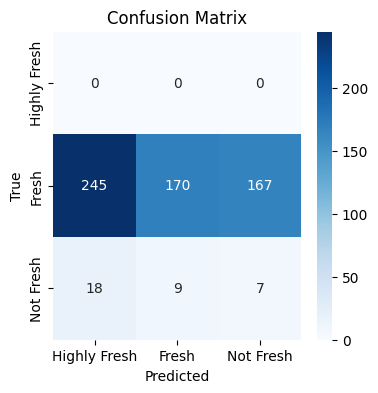

In [69]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Compute the confusion matrix
conf_matrix = confusion_matrix(y_unseen, y_pred_unseen)

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

using same scaler for training and testing

In [70]:
X_scaled = scaler.fit_transform(X)  # Scale the features

In [71]:
# Normalize the features
# scaler = StandardScaler()
X_unseen = scaler.transform(X_unseen)

# Assuming `ann` is your trained MLPClassifier model
# Make predictions on unseen data
y_pred_unseen = ann.predict(X_unseen)

# Evaluate the predictions
print(classification_report(y_unseen, y_pred_unseen))
print("Accuracy:", accuracy_score(y_unseen, y_pred_unseen))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.90      0.03      0.06       582
           2       0.09      0.26      0.14        34

    accuracy                           0.04       616
   macro avg       0.33      0.10      0.07       616
weighted avg       0.86      0.04      0.06       616

Accuracy: 0.04383116883116883


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


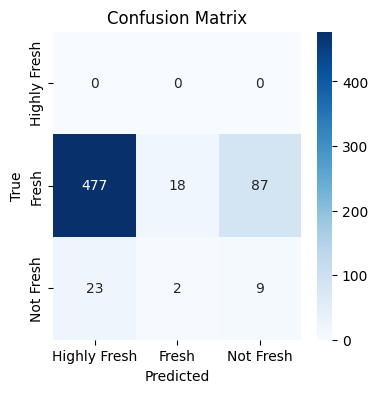

In [72]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Compute the confusion matrix
conf_matrix = confusion_matrix(y_unseen, y_pred_unseen)

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

test tilapia

In [75]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.utils import to_categorical
from sklearn.neural_network import MLPClassifier

# Load the VGG19 model pre-trained on ImageNet
vgg19 = VGG19(weights='imagenet')
# Create a model that outputs activations from the penultimate layer (fc2)
model = Model(inputs=vgg19.input, outputs=vgg19.get_layer('fc2').output)

def extract_features(img_paths, model):
    features = []
    for img_path in tqdm(img_paths):
        img = image.load_img(img_path, target_size=(224, 224))
        img_data = image.img_to_array(img)
        img_data = np.expand_dims(img_data, axis=0)
        img_data = preprocess_input(img_data)
        fc2_features = model.predict(img_data, verbose=0)
        features.append(fc2_features.flatten())
    return np.array(features)

# Define the folder path containing your unseen data
# unseen_data_folder = 'path_to_unseen_data_folder'
unseen_data_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes/Tilapia'

# Prepare a DataFrame for unseen data
data = []
class_mapping = {
    'Highly Fresh': 0,
    'Fresh': 1,
    'Not Fresh': 2
}

# Iterate over the folders in the unseen data folder
for class_dir in os.listdir(unseen_data_folder):
    # Check if the class is one of the classes you trained on
    if class_dir in class_mapping:
        class_label = class_mapping[class_dir]
        class_path = os.path.join(unseen_data_folder, class_dir)
        # List all image files in the class directory
        image_files = os.listdir(class_path)
        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            data.append((img_path, class_label))

# Create a DataFrame
df_unseen_data = pd.DataFrame(data, columns=['img_path', 'class_label'])

# Extract features for unseen data
X_unseen = extract_features(df_unseen_data['img_path'].tolist(), model)

# Convert labels to numerical values (if needed)
y_unseen = df_unseen_data['class_label'].map(class_mapping).values

100%|██████████| 363/363 [05:00<00:00,  1.21it/s]


In [76]:
y_unseen = df_unseen_data['class_label'].values

using different scalers for training and testing

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.94      0.30      0.45       350
           2       0.01      0.08      0.02        13

    accuracy                           0.29       363
   macro avg       0.32      0.12      0.16       363
weighted avg       0.90      0.29      0.44       363

Accuracy: 0.2892561983471074


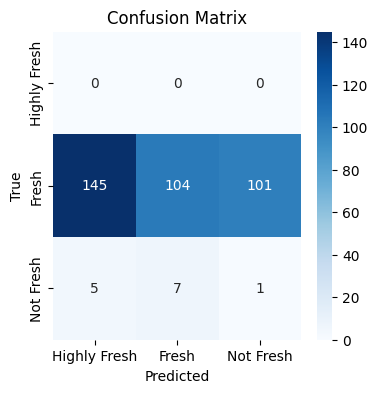

In [77]:
# Normalize the features
scaler = StandardScaler()
X_unseen = scaler.fit_transform(X_unseen)

# Assuming `ann` is your trained MLPClassifier model
# Make predictions on unseen data
y_pred_unseen = ann.predict(X_unseen)

# Evaluate the predictions
print(classification_report(y_unseen, y_pred_unseen))
print("Accuracy:", accuracy_score(y_unseen, y_pred_unseen))


from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Compute the confusion matrix
conf_matrix = confusion_matrix(y_unseen, y_pred_unseen)

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

using same scaler for training and testing

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.04      0.07       350
           2       0.03      0.08      0.05        13

    accuracy                           0.04       363
   macro avg       0.34      0.04      0.04       363
weighted avg       0.97      0.04      0.07       363

Accuracy: 0.03856749311294766


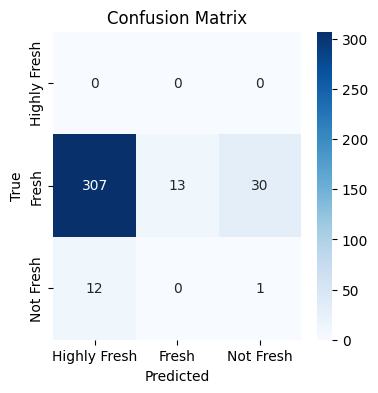

In [78]:
X_scaled = scaler.fit_transform(X)  # Scale the features

# Normalize the features
# scaler = StandardScaler()
X_unseen = scaler.transform(X_unseen)

# Assuming `ann` is your trained MLPClassifier model
# Make predictions on unseen data
y_pred_unseen = ann.predict(X_unseen)

# Evaluate the predictions
print(classification_report(y_unseen, y_pred_unseen))
print("Accuracy:", accuracy_score(y_unseen, y_pred_unseen))

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Compute the confusion matrix
conf_matrix = confusion_matrix(y_unseen, y_pred_unseen)

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    # stratify=y,
                                                    random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Define the ANN model
ann = MLPClassifier(hidden_layer_sizes=(100,), activation='relu',
                    solver='adam', alpha=0.0001, max_iter=500,
                    random_state=42)

# Train the model
ann.fit(X_train, y_train)

# Make predictions
y_pred = ann.predict(X_test)

# Evaluate the model
print(classification_report(y_test.argmax(axis=1),
                            y_pred.argmax(axis=1),
                            target_names=label_mapping.keys()))

print("Accuracy:", accuracy_score(y_test.argmax(axis=1),
                                  y_pred.argmax(axis=1)))


              precision    recall  f1-score   support

Highly Fresh       0.77      0.92      0.84       706
       Fresh       0.83      0.70      0.76       548
   Not Fresh       0.87      0.76      0.81       502

    accuracy                           0.81      1756
   macro avg       0.82      0.80      0.80      1756
weighted avg       0.82      0.81      0.81      1756

Accuracy: 0.8097949886104784


In [ ]:
# prompt: I have a yolov8 eye detection model and I will give you the folder of images or a single image. I have to crop the image with the eye part and then send it to the model for prediction. Also the folder contains good and bad folders which  here refer to both 'Fresh' and 'Highly fresh' for good and 'not fresh' for bad class. give me python code for this

import cv2
import os
from ultralytics import YOLO

# Load the YOLOv8 eye detection model
eye_detector = YOLO('path/to/eye_detection_model.pt')  # Replace with your model path

# Load the fish freshness classification model (assuming it's loaded from previous code)
# ... (code from the preceding section to load the VGG19-based model)

def crop_and_predict(image_folder, output_folder):
  """
  Crops eye regions from images and predicts fish freshness.

  Args:
    image_folder: Path to the folder containing images (with 'good' and 'bad' subfolders).
    output_folder: Path to the folder where cropped eye images will be saved.
  """

  for class_folder in ['good', 'bad']:
    class_path = os.path.join(image_folder, class_folder)
    for img_name in os.listdir(class_path):
      img_path = os.path.join(class_path, img_name)
      img = cv2.imread(img_path)

      # Eye detection
      results = eye_detector(img)

      # Iterate through detected eyes and crop
      for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()  # Assuming bounding boxes are in xyxy format
        for box in boxes:
          x1, y1, x2, y2 = box.astype(int)
          cropped_eye = img[y1:y2, x1:x2]

          # Save cropped eye image
          output_path = os.path.join(output_folder, class_folder, f"{img_name[:-4]}_eye.jpg")
          cv2.imwrite(output_path, cropped_eye)

          # Predict freshness using the VGG19-based model
          features = extract_features(output_path, model)  # Assuming 'model' is the VGG19-based model
          features = scaler.transform(features.reshape(1, -1))  # Reshape and normalize
          prediction = ann.predict(features)

          # Print or store the prediction result
          print(f"Image: {img_name}, Prediction: {prediction}")

# Example usage:
image_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/combined_data'  # Replace with your image folder
output_folder = '/content/cropped_eyes'  # Replace with desired output folder
os.makedirs(output_folder, exist_ok=True)
os.makedirs(os.path.join(output_folder, 'good'), exist_ok=True)
os.makedirs(os.path.join(output_folder, 'bad'), exist_ok=True)

crop_and_predict(image_folder, output_folder)


In [ ]:
! pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 6.0 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-m

In [ ]:
from ultralytics import YOLO
from tqdm import tqdm
import os
import cv2
import numpy as np

In [ ]:
species_test_folder = '/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data/Indian salmon/Bad/Single'
destination_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes/Indian salmon/Not Fresh'
os.makedirs(destination_folder, exist_ok=True)

In [ ]:
# Load the YOLOv8 eye detection model
eye_detection_model_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/detect_eye.pt'
eye_detector = YOLO(eye_detection_model_path)

# Load the YOLOv8 fish segmentation model
fish_segmentation_model_path = '/content/drive/MyDrive/Sowmya /models/segmentation/kartik/fish.pt'
fish_segmentation_model = YOLO(fish_segmentation_model_path)

In [ ]:
def segment_fish(image_path, white_background=False):
    img = cv2.imread(image_path)
    results = fish_segmentation_model(img, conf=0.75,
                                      verbose=False, iou=0.5)
    pred = results[0]
    if len(pred.boxes) == 0:
        return []
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    for i in range(len(masks)):
        mask = masks[i]
        mask_points = mask.astype(int)
        binary_mask = np.zeros((height, width), dtype=np.uint8)
        cv2.fillPoly(binary_mask, [mask_points], 255)
        masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
        x, y, w, h = cv2.boundingRect(mask_points)
        segment_image = np.zeros((height, width, 3), dtype=np.uint8)
        segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
        segment_image = segment_image[y:y+h, x:x+w]
        white_background = False
        if white_background:
            black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
            segment_image[black_mask] = [255, 255, 255]
        seg_img_list.append(segment_image)
    return seg_img_list


def save_cropped_eye(img, filename, output_folder):
    # Eye detection
    results = eye_detector(img, conf=0.1, verbose=False)
    if len(results) == 0:
        return
    # Iterate through detected eyes and crop
    for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()  # Assuming bounding boxes are in xyxy format
        for box in boxes:
            x1, y1, x2, y2 = box.astype(int)
            cropped_eye = img[y1:y2, x1:x2]

            # Save cropped eye image
            output_path = os.path.join(output_folder, filename + '_eye.jpg')
            cv2.imwrite(output_path, cropped_eye)

def prepare_data(image_folder, output_folder):
    for f in tqdm(os.listdir(image_folder)):
        img_path = os.path.join(image_folder, f)
        filename = os.path.splitext(f)[0]
        seg_img_list = segment_fish(img_path)
        if len(seg_img_list) == 0:
            continue
        for i, seg_img in enumerate(seg_img_list):
            save_cropped_eye(seg_img, filename, output_folder)

In [ ]:
prepare_data(species_test_folder, destination_folder)

100%|██████████| 69/69 [03:30<00:00,  3.05s/it]


In [ ]:
species_test_folder = '/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data/Tilapia/Good/Single'
destination_folder = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/warehouse_data/cropped_eyes/Tilapia/Fresh'
os.makedirs(destination_folder, exist_ok=True)

prepare_data(species_test_folder, destination_folder)

100%|██████████| 598/598 [28:13<00:00,  2.83s/it]


In [9]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
def extract_features(img_paths, model):
    features = []
    for img_path in img_paths:
        img = image.load_img(img_path, target_size=(224, 224))
        img_data = image.img_to_array(img)
        img_data = np.expand_dims(img_data, axis=0)
        img_data = preprocess_input(img_data)
        fc2_features = model.predict(img_data, verbose=0)
        features.append(fc2_features.flatten())
    return np.array(features)

In [11]:
def load_vgg19_model():
    vgg19 = VGG19(weights='imagenet')
    model = Model(inputs=vgg19.input, outputs=vgg19.get_layer('fc2').output)
    return model

In [26]:
def prepare_data(df):
    model = load_vgg19_model()
    X = extract_features(df['img_path'].tolist(), model)
    class_mapping = {
    'Highly Fresh': 0,
    'Fresh': 1,
    'Not Fresh': 2
}
    y = df['freshness_label'].map(class_mapping).values
    return X, y

In [13]:
model_save_path = '/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/models'
os.makedirs(model_save_path, exist_ok=True)
%cd {model_save_path}

/content/drive/MyDrive/Sowmya /xzyx7pbr3w-1/models


In [14]:
def save_model_and_scaler(model, scaler, model_name):
    joblib.dump(model, f'{model_name}_model.pkl')
    joblib.dump(scaler, f'{model_name}_scaler.pkl')

def load_model_and_scaler(model_name):
    model = joblib.load(f'{model_name}_model.pkl')
    scaler = joblib.load(f'{model_name}_scaler.pkl')
    return model, scaler

In [32]:
def evaluate_model(y_true, y_pred, class_names, model_name):
    print(classification_report(y_true, y_pred, target_names=class_names))
    print("Accuracy:", accuracy_score(y_true, y_pred))

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()


In [16]:
def train_knn(X_train, y_train):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    knn = KNeighborsClassifier(n_neighbors=10,
                               weights='uniform',
                               metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    return knn, scaler

def train_svm(X_train, y_train):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    svm = SVC(C=1.0, kernel='rbf', gamma='auto',
              tol=0.0001, max_iter=1000)
    svm.fit(X_train_scaled, y_train)
    return svm, scaler

def train_ann(X_train, y_train):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    ann = MLPClassifier(hidden_layer_sizes=(100,),
                        activation='relu', solver='adam',
                        alpha=0.0001, max_iter=500)
    ann.fit(X_train_scaled, y_train)
    return ann, scaler

def train_lr(X_train, y_train):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    lr = LogisticRegression(penalty='l1', C=1.0,
                            solver='saga', tol=0.0001,
                            max_iter=1000)
    lr.fit(X_train_scaled, y_train)
    return lr, scaler

def train_rf(X_train, y_train):
    rf = RandomForestClassifier(n_estimators=500, max_features=5,
                                min_samples_split=5, random_state=42)
    rf.fit(X_train, y_train)
    return rf

def train_rf_scaled(X_train, y_train):
    rf = RandomForestClassifier(n_estimators=500, max_features=5,
                                min_samples_split=5, random_state=42)
    X_train_scaled = scaler.fit_transform(X_train)
    rf.fit(X_train_scaled, y_train)
    return rf, scaler

In [90]:
X.shape, y.shape

((7024, 4096), (7024,))

In [94]:
# Prepare data
# X, y = prepare_data(df)

# Train and save KNN model
knn, scaler_knn = train_knn(X, y)
save_model_and_scaler(knn, scaler_knn, 'knn')
print('KNN model saved successfully!')

# Train and save SVM model
svm, scaler_svm = train_svm(X, y)
save_model_and_scaler(svm, scaler_svm, 'svm')
print('SVM model saved successfully!')

# Train and save ANN model
ann, scaler_ann = train_ann(X, y)
save_model_and_scaler(ann, scaler_ann, 'ann')
print('ANN model saved successfully!')

# Train and save LR model
lr, scaler_lr = train_lr(X, y)
save_model_and_scaler(lr, scaler_lr, 'lr')
print('LR model saved successfully!')

# Train and save RF model
rf = train_rf(X, y)
joblib.dump(rf, 'rf_model.pkl')
print('RF model saved successfully!')

# # Train and save RF model with scaled features
# rf, scaler_rf = train_rf_scaled(X, y)
# save_model_and_scaler(rf, scaler_rf, 'rf_scaled')
# print('RF model with scaled features saved successfully!')

print('All models saved successfully!')

KNN model saved successfully!


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM model saved successfully!
ANN model saved successfully!


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LR model saved successfully!
RF model saved successfully!
All models saved successfully!


using same scaler

In [ ]:
# # Example DataFrame for unseen data
# data_unseen = {
#     'filepath': ['path_to_unseen_image1.jpg', 'path_to_unseen_image2.jpg', ...],
#     'class': [0, 1, 2, ...]
# }

class_mapping = {
    'Highly Fresh': 0,
    'Fresh': 1,
    'Not Fresh': 2
}

df_unseen = test_df
X_unseen, y_unseen = prepare_data(df_unseen)

In [ ]:
y_unseen = np.array([class_mapping[i] for i in y_unseen])

              precision    recall  f1-score   support

Highly Fresh       0.75      0.67      0.71       708
       Fresh       0.51      0.67      0.58       529
   Not Fresh       0.68      0.56      0.61       519

    accuracy                           0.64      1756
   macro avg       0.65      0.63      0.63      1756
weighted avg       0.66      0.64      0.64      1756

Accuracy: 0.6389521640091116


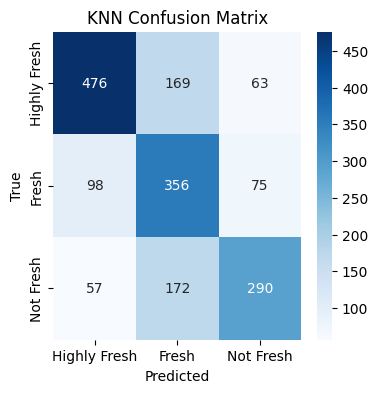

              precision    recall  f1-score   support

Highly Fresh       0.88      0.77      0.82       708
       Fresh       0.69      0.81      0.75       529
   Not Fresh       0.79      0.79      0.79       519

    accuracy                           0.79      1756
   macro avg       0.79      0.79      0.79      1756
weighted avg       0.80      0.79      0.79      1756

Accuracy: 0.7875854214123007


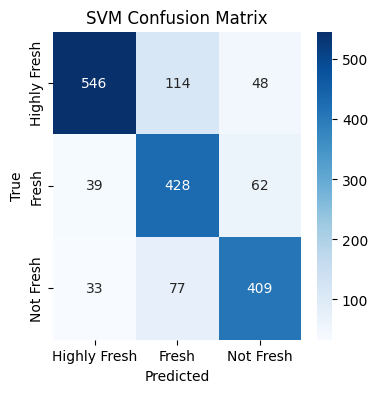

              precision    recall  f1-score   support

Highly Fresh       0.88      0.87      0.87       708
       Fresh       0.77      0.79      0.78       529
   Not Fresh       0.83      0.82      0.83       519

    accuracy                           0.83      1756
   macro avg       0.83      0.83      0.83      1756
weighted avg       0.83      0.83      0.83      1756

Accuracy: 0.8308656036446469


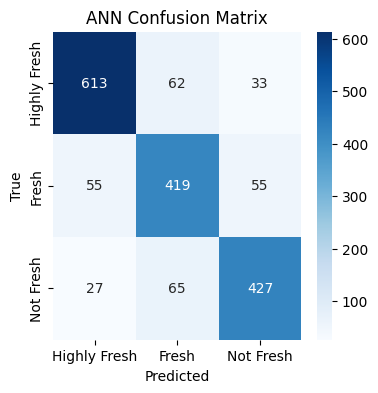

              precision    recall  f1-score   support

Highly Fresh       0.78      0.77      0.77       708
       Fresh       0.63      0.65      0.64       529
   Not Fresh       0.70      0.69      0.69       519

    accuracy                           0.71      1756
   macro avg       0.70      0.70      0.70      1756
weighted avg       0.71      0.71      0.71      1756

Accuracy: 0.7101366742596811


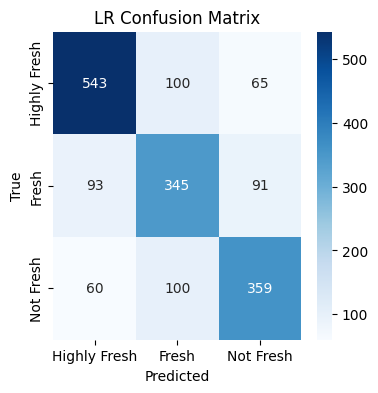

              precision    recall  f1-score   support

Highly Fresh       0.66      0.92      0.77       708
       Fresh       0.77      0.55      0.65       529
   Not Fresh       0.82      0.63      0.72       519

    accuracy                           0.72      1756
   macro avg       0.75      0.70      0.71      1756
weighted avg       0.74      0.72      0.72      1756

Accuracy: 0.7232346241457859


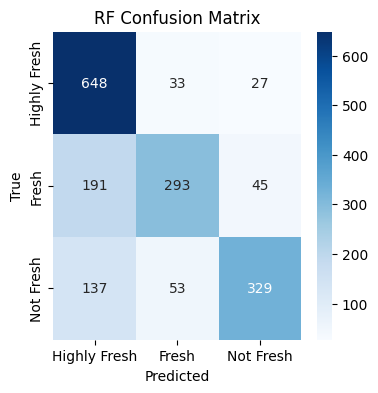

In [35]:
# Load and evaluate KNN model
knn, scaler_knn = load_model_and_scaler('knn')
X_unseen_scaled_knn = scaler_knn.transform(X_unseen)
y_pred_knn = knn.predict(X_unseen_scaled_knn)
evaluate_model(y_unseen, y_pred_knn, class_mapping.keys(), 'KNN')

# Load and evaluate SVM model
svm, scaler_svm = load_model_and_scaler('svm')
X_unseen_scaled_svm = scaler_svm.transform(X_unseen)
y_pred_svm = svm.predict(X_unseen_scaled_svm)
evaluate_model(y_unseen, y_pred_svm, class_mapping.keys(), 'SVM')

# Load and evaluate ANN model
ann, scaler_ann = load_model_and_scaler('ann')
X_unseen_scaled_ann = scaler_ann.transform(X_unseen)
y_pred_ann = ann.predict(X_unseen_scaled_ann)
evaluate_model(y_unseen, y_pred_ann, class_mapping.keys(), 'ANN')

# Load and evaluate LR model
lr, scaler_lr = load_model_and_scaler('lr')
X_unseen_scaled_lr = scaler_lr.transform(X_unseen)
y_pred_lr = lr.predict(X_unseen_scaled_lr)
evaluate_model(y_unseen, y_pred_lr, class_mapping.keys(), 'LR')

# Load and evaluate RF model
rf = joblib.load('rf_model.pkl')
y_pred_rf = rf.predict(X_unseen)
evaluate_model(y_unseen, y_pred_rf, class_mapping.keys(), 'RF')

# # Load and evaluate RF model with scaled data
# rf, scaler_rf = load_model_and_scaler('rf_scaled')
# X_unseen_scaled_rf = scaler_rf.transform(X_unseen)
# y_pred_scaled_rf = rf.predict(X_unseen_scaled_rf)
# evaluate_model(y_unseen, y_pred_scaled_rf, class_mapping.keys())

using different scalers

              precision    recall  f1-score   support

Highly Fresh       0.75      0.67      0.71       708
       Fresh       0.51      0.66      0.58       529
   Not Fresh       0.67      0.56      0.61       519

    accuracy                           0.64      1756
   macro avg       0.64      0.63      0.63      1756
weighted avg       0.66      0.64      0.64      1756

Accuracy: 0.6372437357630979


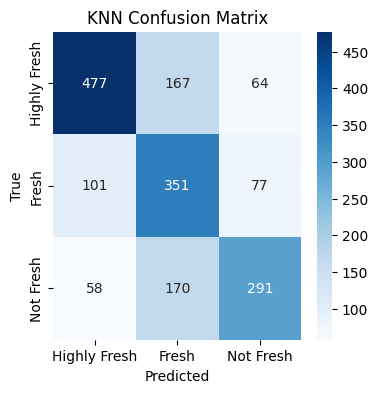

              precision    recall  f1-score   support

Highly Fresh       0.89      0.78      0.83       708
       Fresh       0.70      0.80      0.75       529
   Not Fresh       0.79      0.80      0.79       519

    accuracy                           0.79      1756
   macro avg       0.79      0.80      0.79      1756
weighted avg       0.80      0.79      0.80      1756

Accuracy: 0.7944191343963554


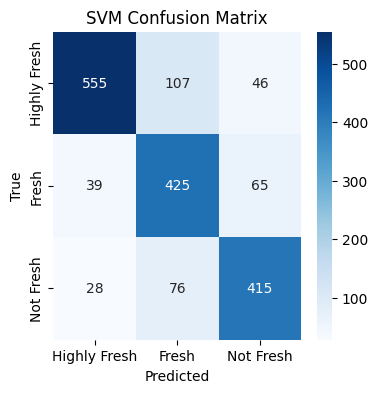

              precision    recall  f1-score   support

Highly Fresh       0.89      0.87      0.88       708
       Fresh       0.77      0.79      0.78       529
   Not Fresh       0.82      0.82      0.82       519

    accuracy                           0.83      1756
   macro avg       0.83      0.83      0.83      1756
weighted avg       0.83      0.83      0.83      1756

Accuracy: 0.8308656036446469


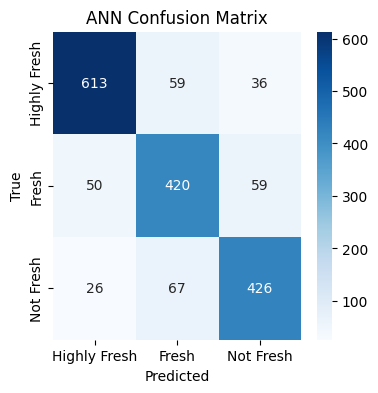

              precision    recall  f1-score   support

Highly Fresh       0.78      0.79      0.79       708
       Fresh       0.64      0.65      0.64       529
   Not Fresh       0.71      0.68      0.70       519

    accuracy                           0.72      1756
   macro avg       0.71      0.71      0.71      1756
weighted avg       0.72      0.72      0.72      1756

Accuracy: 0.7169703872437357


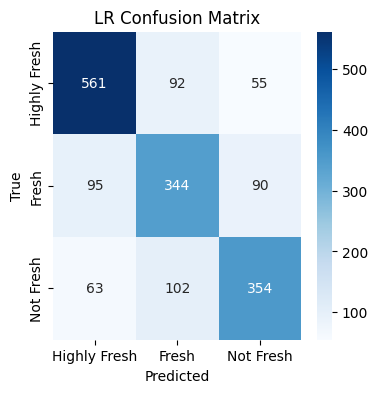

              precision    recall  f1-score   support

Highly Fresh       0.66      0.92      0.77       708
       Fresh       0.77      0.55      0.65       529
   Not Fresh       0.82      0.63      0.72       519

    accuracy                           0.72      1756
   macro avg       0.75      0.70      0.71      1756
weighted avg       0.74      0.72      0.72      1756

Accuracy: 0.7232346241457859


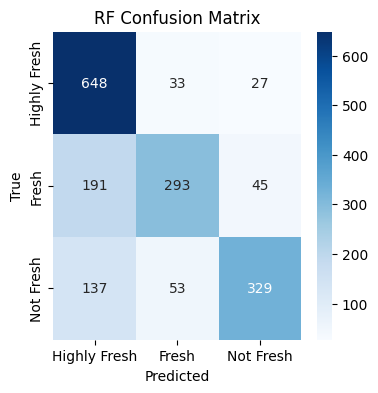

In [36]:
# # Example DataFrame for unseen data
# data_unseen = {
#     'filepath': ['path_to_unseen_image1.jpg', 'path_to_unseen_image2.jpg', ...],
#     'class': [0, 1, 2, ...]
# }

# df_unseen = test_df
# X_unseen, y_unseen = prepare_data(df_unseen)

# Load and evaluate KNN model
knn, scaler_knn = load_model_and_scaler('knn')
scaler_knn = StandardScaler()
X_unseen_scaled_knn = scaler_knn.fit_transform(X_unseen)
y_pred_knn = knn.predict(X_unseen_scaled_knn)
evaluate_model(y_unseen, y_pred_knn, class_mapping.keys(), 'KNN')

# Load and evaluate SVM model
svm, scaler_svm = load_model_and_scaler('svm')
scaler_svm = StandardScaler()
X_unseen_scaled_svm = scaler_svm.fit_transform(X_unseen)
y_pred_svm = svm.predict(X_unseen_scaled_svm)
evaluate_model(y_unseen, y_pred_svm, class_mapping.keys(), 'SVM')

# Load and evaluate ANN model
ann, scaler_ann = load_model_and_scaler('ann')
scaler_ann = StandardScaler()
X_unseen_scaled_ann = scaler_ann.fit_transform(X_unseen)
y_pred_ann = ann.predict(X_unseen_scaled_ann)
evaluate_model(y_unseen, y_pred_ann, class_mapping.keys(), 'ANN')

# Load and evaluate LR model
lr, scaler_lr = load_model_and_scaler('lr')
scaler_lr = StandardScaler()
X_unseen_scaled_lr = scaler_lr.fit_transform(X_unseen)
y_pred_lr = lr.predict(X_unseen_scaled_lr)
evaluate_model(y_unseen, y_pred_lr, class_mapping.keys(), 'LR')

# Load and evaluate RF model
rf = joblib.load('rf_model.pkl')
y_pred_rf = rf.predict(X_unseen)
evaluate_model(y_unseen, y_pred_rf, class_mapping.keys(), 'RF')

# # Load and evaluate RF model with scaled data
# rf, scaler_rf = load_model_and_scaler('rf_scaled')
# scaler_rf = StandardScaler()
# X_unseen_scaled_rf = scaler_rf.transform(X_unseen)
# y_pred_scaled_rf = rf.predict(X_unseen_scaled_rf)
# evaluate_model(y_unseen, y_pred_scaled_rf, class_mapping.keys())